# Flight Delay Prediction — Logistic Regression

**Input:** `train_sample.parquet` (stratified 10% of train, seed=42) + `val.parquet`  
**Target:** `ArrDel15` — binary (1 = arrival ≥ 15 min late)  
**Prediction horizon:** T–2 hours before scheduled departure  

**Pipeline:** `VectorAssembler` → `StandardScaler` → `LogisticRegression`

---

## Metric hierarchy

| Tier | Metric | Purpose |
|------|--------|---------|
| 1 — Primary | AUC-PR | Imbalance-aware; random baseline = class prevalence (~0.19) |
| 1 — Primary | ΔAUC-PR (val → test) | Temporal robustness signal across the distributional shift |
| 2 — Model selection | AUC-ROC | Threshold-independent model ranking |
| 2 — Stability | Monthly class-1 F1 stddev (2023 val) | Within-period stability score |
| 3 — Operational | Class-1 F1 / Precision / Recall | At threshold locked on 2023 val set |
| Reference only | Accuracy, weighted F1/Precision/Recall | Misleading at 19% class prevalence — Useful for internal reference, not for reporting |

> **Test set discipline:** Test set evaluation is intentionally deferred. The optimal threshold is locked on the 2023 validation set and applied once — and only once — to the 2024 test set after all models are finalized.

---
## 1. Environment Setup

Installs OpenJDK 11 and PySpark, then locates the Java home directory for Spark to use. Run once per Colab session.

In [22]:
!apt-get update -qq
!apt-get install -y openjdk-11-jdk-headless -qq
!pip install pyspark --quiet

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid

In [23]:
import os, subprocess

result = subprocess.run(
    "java -XshowSettings:property -version 2>&1 | grep 'java.home'",
    shell=True, capture_output=True, text=True
)
os.environ['JAVA_HOME'] = result.stdout.strip().split('=')[-1].strip()
print('JAVA_HOME:', os.environ['JAVA_HOME'])

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64


In [24]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName('FlightDelay_LogReg')
    .master('local[*]')
    .config('spark.driver.memory', '40g')
    .config('spark.driver.maxResultSize', '8g')
    .config('spark.memory.fraction', '0.8')
    .config('spark.memory.storageFraction', '0.3')
    .config('spark.sql.shuffle.partitions', '200')
    .getOrCreate()
)
spark.conf.set('spark.sql.parquet.int96RebaseModeInRead', 'CORRECTED')
spark.conf.set('spark.sql.legacy.parquet.nanosAsLong', 'true')
spark.conf.set('spark.sql.parquet.mergeSchema', 'false')
spark.conf.set('spark.hadoop.parquet.enable.summary-metadata', 'false')
spark.sparkContext.setLogLevel('WARN')
print('Spark version:', spark.version)

Spark version: 4.0.2


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 2. Load Data

Reads the pre-built 10% stratified training sample and the full 2023 validation set from Google Drive. Both files are copied to local NVMe SSD before Spark reads them — Drive I/O is the primary bottleneck in Colab and this step removes it from all subsequent Spark operations.

No full training set is loaded. No test set is loaded at any point in this notebook.

In [26]:
from pyspark.sql import functions as F
import shutil, os

SAMPLE_PATH = '/content/drive/MyDrive/OMDS Capstone/Data/flights_sample'
LOCAL       = '/content/local_data'
os.makedirs(LOCAL, exist_ok=True)

for name in ['train_sample', 'val']:
    shutil.copytree(
        f'{SAMPLE_PATH}/{name}.parquet',
        f'{LOCAL}/{name}.parquet',
        dirs_exist_ok=True
    )
    print(f'Copied {name} to local SSD')

train_df = spark.read.parquet(f'{LOCAL}/train_sample.parquet')
val_df   = spark.read.parquet(f'{LOCAL}/val.parquet')

print(f'\nTrain sample rows : {train_df.count():>10,}')
print(f'Val rows          : {val_df.count():>10,}')

Copied train_sample to local SSD
Copied val to local SSD

Train sample rows :  9,346,252
Val rows          :  6,743,403


---
## 3. Feature Definition

Canonical feature list — must match `FlightDelay_DataPrep.ipynb` exactly. Features are grouped by type and collinear or redundant features are dropped with the rationale noted inline.

| Group | Features retained | Dropped |
|---|---|---|
| Schedule / calendar | `Month`, `DayOfWeek`, `dep_hour`, `Distance`, `CRSElapsedTime`, `is_holiday` | `is_weekend` — derivable from `DayOfWeek` |
| Carrier rolling | `carrier_delay_rate_30d` | `carrier_delay_rate_90d` — collinear with 30d |
| Airport congestion | `origin_departures_3h` | — |
| Target encoded | `origin_delay_rate`, `dest_delay_rate` | — |
| Weather flags (origin) | `origin_is_rain`, `origin_is_snow`, `origin_is_fog`, `origin_severe_weather` | `origin_low_visibility` — captured by continuous `origin_visibility`; `origin_high_wind` — captured by `origin_wind_kts` |
| Weather flags (dest) | `dest_is_rain`, `dest_is_snow`, `dest_is_fog`, `dest_severe_weather` | same rationale as origin |
| Weather continuous (origin) | `origin_visibility`, `origin_wind_kts`, `origin_precip_in` | `origin_gust_kts` — collinear with `origin_wind_kts` |
| Weather continuous (dest) | `dest_visibility`, `dest_wind_kts`, `dest_precip_in` | same rationale as origin |

In [27]:
SCHEDULE_FEATURES = [
    'Month', 'DayOfWeek', 'dep_hour', 'Distance', 'CRSElapsedTime',
    'is_holiday',
]
ENGINEERED_FEATURES = [
    'carrier_delay_rate_30d',
    'origin_departures_3h',
    'origin_delay_rate', 'dest_delay_rate',
]
WEATHER_FLAGS = [
    'origin_is_rain', 'origin_is_snow', 'origin_is_fog', 'origin_severe_weather',
    'dest_is_rain',   'dest_is_snow',   'dest_is_fog',   'dest_severe_weather',
]
WEATHER_CONTINUOUS = [
    'origin_visibility', 'origin_wind_kts', 'origin_precip_in',
    'dest_visibility',   'dest_wind_kts',   'dest_precip_in',
]

FEATURE_COLS = SCHEDULE_FEATURES + ENGINEERED_FEATURES + WEATHER_FLAGS + WEATHER_CONTINUOUS
TARGET_COL   = 'ArrDel15'
WEIGHT_COL   = 'class_weight'

print(f'Total features : {len(FEATURE_COLS)}')

Total features : 24


---
## 4. Preprocessing Pipeline — Definition

`VectorAssembler` stacks all feature columns into a single dense vector. `StandardScaler` normalises to mean=0, std=1 and is fit exclusively on the training sample — the same scaler is applied without refitting to validation and test to prevent data leakage. `standardization=False` is set on `LogisticRegression` to prevent double-scaling since the scaler already handles it.

In [28]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression

assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='raw_features',
    handleInvalid='skip'
)
scaler = StandardScaler(
    inputCol='raw_features',
    outputCol='features',
    withMean=True,
    withStd=True
)
prep_pipeline = Pipeline(stages=[assembler, scaler])

print('Pipeline objects defined.')
print(f'Feature vector length: {len(FEATURE_COLS)}')

Pipeline objects defined.
Feature vector length: 24


---
## 5. Evaluation Helper

Central evaluation function used in §§7–9. Results are printed and returned in tier order matching the project metric hierarchy.

**AUC-PR** is the primary metric for this project. Unlike AUC-ROC, whose random baseline is always 0.5 regardless of class balance, AUC-PR's random baseline equals class prevalence (~0.19). A model reaching AUC-PR=0.38 has roughly doubled performance over chance — a concrete, interpretable claim. AUC-PR is also more sensitive to the distributional shift from 2023 validation to 2024 test, making ΔAUC-PR the primary temporal robustness signal.

**Weighted metrics** (accuracy, weighted F1/precision/recall) are computed and printed for completeness but clearly labeled as reference-only. With ~81% of flights being on time, these metrics are dominated by class 0 performance and will look deceptively strong even in a poor model. They are not used as headline numbers anywhere in this project.

In [29]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array

def evaluate_predictions(predictions, label_col=TARGET_COL, threshold=0.5, split_name=''):
    """
    Compute and report metrics in tier order.

    Returns a dict with keys:
      Tier 1:  auc_pr
      Tier 2:  auc_roc
      Tier 3:  f1_class1, prec_class1, rec_class1, tp, fp, fn, tn
      Ref:     f1_weighted, accuracy
    """
    auc_roc = BinaryClassificationEvaluator(
        labelCol=label_col, rawPredictionCol='rawPrediction', metricName='areaUnderROC'
    ).evaluate(predictions)
    auc_pr = BinaryClassificationEvaluator(
        labelCol=label_col, rawPredictionCol='rawPrediction', metricName='areaUnderPR'
    ).evaluate(predictions)

    preds_t = predictions.withColumn(
        'pred_label',
        (vector_to_array(F.col('probability'))[1] >= threshold).cast('double')
    )

    cm_data = (
        preds_t
        .groupBy(F.col(label_col).cast('int').alias('actual'),
                 F.col('pred_label').cast('int').alias('predicted'))
        .count().collect()
    )
    counts = {(r['actual'], r['predicted']): r['count'] for r in cm_data}
    tp = counts.get((1, 1), 0); fp = counts.get((0, 1), 0)
    fn = counts.get((1, 0), 0); tn = counts.get((0, 0), 0)
    n_total    = tp + fp + fn + tn
    prevalence = (tp + fn) / n_total if n_total > 0 else 0

    prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_1  = 2 * prec1 * rec1 / (prec1 + rec1) if (prec1 + rec1) > 0 else 0.0

    mc       = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol='pred_label')
    f1_wtd   = mc.setMetricName('f1').evaluate(preds_t)
    prec_wtd = mc.setMetricName('weightedPrecision').evaluate(preds_t)
    rec_wtd  = mc.setMetricName('weightedRecall').evaluate(preds_t)
    accuracy = mc.setMetricName('accuracy').evaluate(preds_t)

    header = f'  {split_name}' if split_name else '  Evaluation results'
    bar    = '=' * max(len(header), 52)
    print(f'\n{bar}')
    print(header)
    print(bar)

    print(f'\n  ── Tier 1: Primary (imbalance-aware) ──────────────')
    print(f'  AUC-PR            : {auc_pr:.4f}   [random baseline ≈ {prevalence:.4f}]')

    print(f'\n  ── Tier 2: Model ranking (threshold-independent) ──')
    print(f'  AUC-ROC           : {auc_roc:.4f}   [random baseline = 0.5000]')

    print(f'\n  ── Tier 3: Operational  (threshold = {threshold}) ─────')
    print(f'  Class-1 F1        : {f1_1:.4f}')
    print(f'  Class-1 Precision : {prec1:.4f}')
    print(f'  Class-1 Recall    : {rec1:.4f}')
    print(f'  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')

    print(f'\n  ── Reference only (weighted — dominated by class 0) ')
    print(f'  Accuracy          : {accuracy:.4f}')
    print(f'  Weighted F1       : {f1_wtd:.4f}')
    print(f'  Weighted Precision: {prec_wtd:.4f}')
    print(f'  Weighted Recall   : {rec_wtd:.4f}')

    return dict(
        auc_pr=auc_pr, auc_roc=auc_roc,
        f1_class1=f1_1, prec_class1=prec1, rec_class1=rec1,
        tp=tp, fp=fp, fn=fn, tn=tn,
        f1_weighted=f1_wtd, accuracy=accuracy
    )

---
## 6. Prepare Training & Validation Data

Four steps in sequence:

1. **Class weights** — compute the 0:1 imbalance ratio from the training sample and add a `class_weight` column. All three models use the same weighting scheme for a fair comparison.
2. **Weather null imputation** — fill missing weather values with 0 (calm/clear baseline) on both splits. Applied before pipeline fitting so the scaler sees imputed values.
3. **Fit preprocessing pipeline** — scaler parameters are derived from training data only. The same fitted pipeline is applied to validation and will be applied to test without refitting.
4. **Materialise and cache** — `train_prep` is checkpointed then cached to break Spark's lazy evaluation lineage and avoid recomputation. `val_prep` is written to local SSD and reloaded fresh before each model cell to avoid holding two large feature matrices in RAM simultaneously.

In [30]:
CKPT_DIR      = '/content/local_data/checkpoints'
VAL_PREP_PATH = '/content/local_data/val_prep.parquet'
os.makedirs(CKPT_DIR, exist_ok=True)
spark.sparkContext.setCheckpointDir(CKPT_DIR)
print('Checkpoint dir set.')

print('Computing class counts...')
counts_map      = {r[TARGET_COL]: r['count'] for r in train_df.groupBy(TARGET_COL).count().collect()}
imbalance_ratio = counts_map[0] / counts_map[1]
print(f'Not delayed : {counts_map[0]:>10,}')
print(f'Delayed     : {counts_map[1]:>10,}')
print(f'Imbalance   : {imbalance_ratio:.2f}:1  →  class_weight applied to positives')

train_df = train_df.withColumn(
    WEIGHT_COL,
    F.when(F.col(TARGET_COL) == 1, imbalance_ratio).otherwise(F.lit(1.0))
)

fill_map = {col: 0 for col in WEATHER_FLAGS + WEATHER_CONTINUOUS}
train_df = train_df.fillna(fill_map)
val_df   = val_df.fillna(fill_map)
print(f'Weather nulls filled with 0 ({len(fill_map)} columns).')

print('Fitting preprocessing pipeline on training sample...')
prep_model = prep_pipeline.fit(train_df)
print('Pipeline fitted.')

print('Checkpointing train_prep...')
train_prep = prep_model.transform(train_df).checkpoint()
train_prep.cache()
n = train_prep.count()
print(f'train_prep materialised: {n:,} rows.')

n_before = train_df.count()
dropped  = n_before - n
print(f'Rows dropped by VectorAssembler (nulls): {dropped:,}  ({dropped/n_before*100:.2f}%)')
if dropped / n_before > 0.01:
    print('WARNING: >1% of training rows dropped — review non-weather null imputation.')

train_df.unpersist()

print(f'Writing val_prep to {VAL_PREP_PATH}...')
prep_model.transform(val_df).coalesce(8).write.mode('overwrite').parquet(VAL_PREP_PATH)
print('val_prep written to local SSD.')

Checkpoint dir set.
Computing class counts...
Not delayed :  7,675,180
Delayed     :  1,671,072
Imbalance   : 4.59:1  →  class_weight applied to positives
Weather nulls filled with 0 (14 columns).
Fitting preprocessing pipeline on training sample...
Pipeline fitted.
Checkpointing train_prep...
train_prep materialised: 9,346,252 rows.
Rows dropped by VectorAssembler (nulls): 0  (0.00%)
Writing val_prep to /content/local_data/val_prep.parquet...
val_prep written to local SSD.


---
## 7. Regularisation Sweep

Sweeps `regParam` over a log-scale grid to identify the best-regularised model. Model selection uses **AUC-ROC** because it is threshold-independent, keeping model selection and threshold tuning as separate decisions.

**AUC-PR is reported alongside AUC-ROC for every candidate.** If the two metrics produce different top-ranked models, the AUC-PR leader warrants further investigation — AUC-PR is the more informative metric under class imbalance and a divergence suggests the AUC-ROC winner may be achieving high discrimination partly by scoring non-delayed flights confidently rather than by genuinely catching delays.

Pure L2 regularisation (`elasticNetParam=0.0`) is used throughout. The feature set is dense and low-dimensional enough that L1 sparsity is not needed. `val_prep` is reloaded from SSD before each fit to avoid holding two large feature matrices in RAM.

In [31]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

auc_roc_eval = BinaryClassificationEvaluator(
    labelCol=TARGET_COL, rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)
auc_pr_eval = BinaryClassificationEvaluator(
    labelCol=TARGET_COL, rawPredictionCol='rawPrediction', metricName='areaUnderPR'
)
print('Evaluators ready.')

Evaluators ready.


In [32]:
REG_PARAMS = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

sweep_results = []
print(f"{'Model':<6} {'regParam':>10} {'AUC-ROC':>10} {'AUC-PR':>10} {'iters':>8}")
print('-' * 50)

for i, reg in enumerate(REG_PARAMS):
    label    = chr(ord('A') + i)
    val_prep = spark.read.parquet(VAL_PREP_PATH)

    lr = LogisticRegression(
        featuresCol='features', labelCol=TARGET_COL, weightCol=WEIGHT_COL,
        regParam=reg, elasticNetParam=0.0, maxIter=100, standardization=False
    )
    model  = lr.fit(train_prep)
    preds  = model.transform(val_prep)
    auc    = auc_roc_eval.evaluate(preds)
    aucpr  = auc_pr_eval.evaluate(preds)
    iters  = model.summary.totalIterations
    preds.unpersist()

    sweep_results.append((label, reg, auc, aucpr, iters, model))
    print(f'{label:<6} {reg:>10.4f} {auc:>10.4f} {aucpr:>10.4f} {iters:>8}')

if sweep_results[0][2] == max(r[2] for r in sweep_results):
    print('WARNING: Best AUC-ROC is at the lowest regParam — consider extending the grid lower.')
if sweep_results[-1][2] == max(r[2] for r in sweep_results):
    print('WARNING: Best AUC-ROC is at the highest regParam — consider extending the grid higher.')

Model    regParam    AUC-ROC     AUC-PR    iters
--------------------------------------------------
A          0.0001     0.6766     0.3533       29
B          0.0005     0.6766     0.3533       27
C          0.0010     0.6766     0.3533       27
D          0.0050     0.6765     0.3533       24
E          0.0100     0.6764     0.3532       25
F          0.0500     0.6760     0.3529       17
G          0.1000     0.6754     0.3523       14
H          0.5000     0.6705     0.3457       10


In [33]:
best_roc  = max(sweep_results, key=lambda x: x[2])
best_pr   = max(sweep_results, key=lambda x: x[3])
label, best_reg, best_auc, best_aucpr, best_iters, best_model = best_roc

print('Sweep summary:')
print(f"{'Model':<8} {'regParam':>10} {'AUC-ROC':>10} {'AUC-PR':>10} {'iters':>8}")
print('-' * 52)
for row in sweep_results:
    tag = ''
    if row[0] == best_roc[0] and row[0] == best_pr[0]:
        tag = ' <-- best (both)'
    elif row[0] == best_roc[0]:
        tag = ' <-- best AUC-ROC'
    elif row[0] == best_pr[0]:
        tag = ' <-- best AUC-PR'
    print(f"{row[0]:<8} {row[1]:>10.4f} {row[2]:>10.4f} {row[3]:>10.4f} {row[4]:>8}{tag}")

if best_roc[0] != best_pr[0]:
    print(f'\nRANKING DIVERGENCE: AUC-ROC favours Model {best_roc[0]} (regParam={best_roc[1]}), '
          f'AUC-PR favours Model {best_pr[0]} (regParam={best_pr[1]}).')
    print('Proceeding with AUC-ROC winner for model selection. '
          'Investigate AUC-PR leader if overall AUC-PR is notably higher.')
else:
    print(f'\nNo ranking divergence. Both metrics select Model {best_roc[0]}.')

print(f'\nSelected: Model {label}  regParam={best_reg}  AUC-ROC={best_auc:.4f}  AUC-PR={best_aucpr:.4f}')

import pandas as pd
coef_df = (
    pd.DataFrame({'feature': FEATURE_COLS, 'coefficient': best_model.coefficients.toArray()})
    .assign(abs_coef=lambda d: d.coefficient.abs())
    .sort_values('abs_coef', ascending=False)
    .drop(columns='abs_coef')
)
print('\nFeature coefficients — selected model (sorted by |coef|):')
print(coef_df.to_string(index=False))

Sweep summary:
Model      regParam    AUC-ROC     AUC-PR    iters
----------------------------------------------------
A            0.0001     0.6766     0.3533       29 <-- best AUC-ROC
B            0.0005     0.6766     0.3533       27 <-- best AUC-PR
C            0.0010     0.6766     0.3533       27
D            0.0050     0.6765     0.3533       24
E            0.0100     0.6764     0.3532       25
F            0.0500     0.6760     0.3529       17
G            0.1000     0.6754     0.3523       14
H            0.5000     0.6705     0.3457       10

RANKING DIVERGENCE: AUC-ROC favours Model A (regParam=0.0001), AUC-PR favours Model B (regParam=0.0005).
Proceeding with AUC-ROC winner for model selection. Investigate AUC-PR leader if overall AUC-PR is notably higher.

Selected: Model A  regParam=0.0001  AUC-ROC=0.6766  AUC-PR=0.3533

Feature coefficients — selected model (sorted by |coef|):
               feature  coefficient
carrier_delay_rate_30d     0.403215
              dep_hou

---
## 8. Threshold Tuning — Validation Set

The default decision threshold of 0.5 assumes balanced classes. With ~19% positives, a lower threshold recovers delay recall at a modest precision cost. The threshold is selected by maximising **class-1 F1** on the 2023 validation set.

**Threshold lock-in policy:** The threshold selected here is recorded in model metadata and applied identically to the 2024 test set. It is not re-tuned on test data under any circumstances. This same policy applies to the random forest and gradient boosting models — each model's threshold is independently tuned on 2023 val and then frozen.

In [34]:
val_prep       = spark.read.parquet(VAL_PREP_PATH)
val_preds_best = best_model.transform(val_prep)
val_with_prob  = val_preds_best.withColumn(
    'prob_pos', vector_to_array(F.col('probability'))[1]
).cache()

THRESHOLDS       = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]
threshold_results = []

print(f"{'Threshold':>10} {'F1_cls1':>9} {'Prec_cls1':>11} {'Rec_cls1':>10} {'F1_wtd':>8}")
print('-' * 55)

for t in THRESHOLDS:
    preds_t = val_with_prob.withColumn(
        'thresh_pred', (F.col('prob_pos') >= t).cast('double')
    )
    tp = preds_t.filter((F.col('thresh_pred') == 1) & (F.col(TARGET_COL) == 1)).count()
    fp = preds_t.filter((F.col('thresh_pred') == 1) & (F.col(TARGET_COL) == 0)).count()
    fn = preds_t.filter((F.col('thresh_pred') == 0) & (F.col(TARGET_COL) == 1)).count()

    prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_c1 = 2 * prec1 * rec1 / (prec1 + rec1) if (prec1 + rec1) > 0 else 0.0
    f1_wtd = MulticlassClassificationEvaluator(
        labelCol=TARGET_COL, predictionCol='thresh_pred', metricName='f1'
    ).evaluate(preds_t)

    threshold_results.append((t, f1_c1, prec1, rec1, f1_wtd))
    print(f'{t:>10.2f} {f1_c1:>9.4f} {prec1:>11.4f} {rec1:>10.4f} {f1_wtd:>8.4f}')

best_threshold = max(threshold_results, key=lambda x: x[1])[0]
if best_threshold == THRESHOLDS[-1]:
    print('WARNING: Optimal threshold is at the sweep ceiling — extend THRESHOLDS further.')
else:
    print(f'\nOptimal threshold (class-1 F1): {best_threshold}')

 Threshold   F1_cls1   Prec_cls1   Rec_cls1   F1_wtd
-------------------------------------------------------
      0.20    0.3421      0.2064     0.9986   0.0796
      0.25    0.3463      0.2099     0.9904   0.1242
      0.30    0.3552      0.2174     0.9695   0.2120
      0.35    0.3680      0.2293     0.9314   0.3253
      0.40    0.3832      0.2455     0.8731   0.4412
      0.45    0.3975      0.2653     0.7929   0.5433
      0.50    0.4082      0.2893     0.6932   0.6261
      0.55    0.4097      0.3166     0.5804   0.6859
      0.60    0.3962      0.3471     0.4615   0.7248
      0.65    0.3626      0.3816     0.3455   0.7456
      0.70    0.3065      0.4196     0.2414   0.7509
      0.75    0.2266      0.4585     0.1505   0.7438
      0.80    0.1404      0.5051     0.0816   0.7306
      0.85    0.0678      0.5603     0.0361   0.7173

Optimal threshold (class-1 F1): 0.55


In [35]:
val_metrics = evaluate_predictions(
    val_preds_best,
    threshold=best_threshold,
    split_name=f'Logistic Regression — 2023 Validation  (regParam={best_reg}, threshold={best_threshold})'
)


  Logistic Regression — 2023 Validation  (regParam=0.0001, threshold=0.55)

  ── Tier 1: Primary (imbalance-aware) ──────────────
  AUC-PR            : 0.3533   [random baseline ≈ 0.2056]

  ── Tier 2: Model ranking (threshold-independent) ──
  AUC-ROC           : 0.6766   [random baseline = 0.5000]

  ── Tier 3: Operational  (threshold = 0.55) ─────
  Class-1 F1        : 0.4097
  Class-1 Precision : 0.3166
  Class-1 Recall    : 0.5804
  TP=804,905  FP=1,737,488  FN=581,794  TN=3,619,216

  ── Reference only (weighted — dominated by class 0) 
  Accuracy          : 0.6561
  Weighted F1       : 0.6859
  Weighted Precision: 0.7495
  Weighted Recall   : 0.6561


---
## 9. Monthly Stability Analysis — 2023 Validation Set

Partitions the 2023 validation set by calendar month and computes class-1 F1 for each of the 12 months using the locked threshold from §8.

The **standard deviation of the monthly F1 series** is this model's within-year stability score. It is the primary comparator between logistic regression, random forest, and gradient boosting when the 2024 test results are later reported. A model with lower monthly F1 stddev has more consistent delay-detection ability across seasonal operational patterns — a meaningful practical advantage even if its mean F1 is slightly lower than a competitor.

The `Month` column is preserved in `val_prep` because the Spark pipeline appends the `features` column without dropping the originals.

In [36]:
import statistics

monthly_results = []
print(f"{'Month':>6} {'F1_cls1':>9} {'Prec_cls1':>11} {'Rec_cls1':>10} {'n_delayed':>11} {'n_total':>9}")
print('-' * 62)

for month in range(1, 13):
    val_month = spark.read.parquet(VAL_PREP_PATH).filter(F.col('Month') == month)
    preds_m   = best_model.transform(val_month)
    preds_t   = preds_m.withColumn(
        'pred_label',
        (vector_to_array(F.col('probability'))[1] >= best_threshold).cast('double')
    )

    cm_data = (
        preds_t
        .groupBy(F.col(TARGET_COL).cast('int').alias('actual'),
                 F.col('pred_label').cast('int').alias('predicted'))
        .count().collect()
    )
    counts  = {(r['actual'], r['predicted']): r['count'] for r in cm_data}
    tp = counts.get((1, 1), 0); fp = counts.get((0, 1), 0)
    fn = counts.get((1, 0), 0); tn = counts.get((0, 0), 0)
    n_total   = tp + fp + fn + tn
    n_delayed = tp + fn

    prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_1  = 2 * prec1 * rec1 / (prec1 + rec1) if (prec1 + rec1) > 0 else 0.0

    monthly_results.append((month, f1_1, prec1, rec1, n_delayed, n_total))
    print(f'{month:>6} {f1_1:>9.4f} {prec1:>11.4f} {rec1:>10.4f} {n_delayed:>11,} {n_total:>9,}')

f1_vals = [r[1] for r in monthly_results]
monthly_f1_mean = statistics.mean(f1_vals)
monthly_f1_std  = statistics.stdev(f1_vals)
worst_month     = monthly_results[f1_vals.index(min(f1_vals))]
best_month      = monthly_results[f1_vals.index(max(f1_vals))]

print(f'\n  Mean class-1 F1   : {monthly_f1_mean:.4f}')
print(f'  Std class-1 F1    : {monthly_f1_std:.4f}  ← stability score (lower = more stable)')
print(f'  Min class-1 F1    : {min(f1_vals):.4f}  (month {worst_month[0]})')
print(f'  Max class-1 F1    : {max(f1_vals):.4f}  (month {best_month[0]})')
print(f'  Range             : {max(f1_vals) - min(f1_vals):.4f}')

 Month   F1_cls1   Prec_cls1   Rec_cls1   n_delayed   n_total
--------------------------------------------------------------
     1    0.3959      0.2718     0.7287     116,713   527,197
     2    0.3571      0.3080     0.4246      92,969   492,747
     3    0.4348      0.3358     0.6167     136,044   571,533
     4    0.4377      0.3268     0.6624     125,882   550,249
     5    0.3798      0.2958     0.5304     104,119   575,429
     6    0.4851      0.4158     0.5822     152,268   562,804
     7    0.5076      0.3728     0.7954     167,080   585,058
     8    0.4211      0.2951     0.7345     128,439   592,142
     9    0.3600      0.3036     0.4422     104,699   560,887
    10    0.3121      0.2545     0.4033      92,985   596,003
    11    0.2879      0.2641     0.3165      76,348   562,413
    12    0.3122      0.2641     0.3817      89,153   566,941

  Mean class-1 F1   : 0.3909
  Std class-1 F1    : 0.0693  ← stability score (lower = more stable)
  Min class-1 F1    : 0.2879  (

---
## 10. Save Model & Metadata

Saves the fitted preprocessing pipeline, the best logistic regression model, and a JSON metadata file to Google Drive.

The **preprocessing pipeline is saved separately** so it can be loaded by the random forest and gradient boosting notebooks without refitting. This ensures all three models receive identically scaled features.

**Test metrics are intentionally absent.** The `test_*` fields are included as null placeholders — they will be populated once in a dedicated comparative evaluation notebook after all three models are finalised. The `monthly_f1_std` field is the stability score from §9 and will be the primary comparator in that notebook.

In [37]:
import json

MODEL_BASE = '/content/drive/MyDrive/OMDS Capstone/Models/logreg'

prep_model.write().overwrite().save(f'{MODEL_BASE}/prep_pipeline')
print('Saved: prep_pipeline')

best_model.write().overwrite().save(f'{MODEL_BASE}/lr_model')
print('Saved: lr_model')

metadata = {
    'model_type'         : 'LogisticRegression',
    'training_data'      : 'train_sample.parquet (stratified 10%, seed=42)',
    'reg_param'          : best_reg,
    'elastic_net_param'  : 0.0,
    'max_iter'           : 100,
    'optimal_threshold'  : best_threshold,
    'feature_cols'       : FEATURE_COLS,
    'target_col'         : TARGET_COL,
    'val_auc_pr'         : round(val_metrics['auc_pr'],        4),
    'val_auc_roc'        : round(val_metrics['auc_roc'],       4),
    'val_f1_class1'      : round(val_metrics['f1_class1'],     4),
    'val_prec_class1'    : round(val_metrics['prec_class1'],   4),
    'val_rec_class1'     : round(val_metrics['rec_class1'],    4),
    'val_f1_weighted'    : round(val_metrics['f1_weighted'],   4),
    'val_accuracy'       : round(val_metrics['accuracy'],      4),
    'monthly_f1_mean'    : round(monthly_f1_mean,              4),
    'monthly_f1_std'     : round(monthly_f1_std,               4),
    'monthly_f1_by_month': {r[0]: round(r[1], 4) for r in monthly_results},
    'test_auc_pr'        : None,
    'test_auc_roc'       : None,
    'test_f1_class1'     : None,
    'test_prec_class1'   : None,
    'test_rec_class1'    : None,
    'test_monthly_f1_std': None,
}

with open(f'{MODEL_BASE}/metadata.json', 'w') as fh:
    json.dump(metadata, fh, indent=2)
print('Saved: metadata.json')
print()
print(json.dumps(metadata, indent=2))

Saved: prep_pipeline
Saved: lr_model
Saved: metadata.json

{
  "model_type": "LogisticRegression",
  "training_data": "train_sample.parquet (stratified 10%, seed=42)",
  "reg_param": 0.0001,
  "elastic_net_param": 0.0,
  "max_iter": 100,
  "optimal_threshold": 0.55,
  "feature_cols": [
    "Month",
    "DayOfWeek",
    "dep_hour",
    "Distance",
    "CRSElapsedTime",
    "is_holiday",
    "carrier_delay_rate_30d",
    "origin_departures_3h",
    "origin_delay_rate",
    "dest_delay_rate",
    "origin_is_rain",
    "origin_is_snow",
    "origin_is_fog",
    "origin_severe_weather",
    "dest_is_rain",
    "dest_is_snow",
    "dest_is_fog",
    "dest_severe_weather",
    "origin_visibility",
    "origin_wind_kts",
    "origin_precip_in",
    "dest_visibility",
    "dest_wind_kts",
    "dest_precip_in"
  ],
  "target_col": "ArrDel15",
  "val_auc_pr": 0.3533,
  "val_auc_roc": 0.6766,
  "val_f1_class1": 0.4097,
  "val_prec_class1": 0.3166,
  "val_rec_class1": 0.5804,
  "val_f1_weighted": 0

---
## 11. Test Set Evaluation

The 2024 test set is loaded, preprocessed using the pipeline fitted in Section 6, and scored using the model and threshold locked in Sections 7 and 8. No parameters are adjusted after seeing these results.

**ΔAUC-PR** (val → test) is our temporal robustness metric. It measures how much of the model's discrimination ability survives the distributional shift from the 2023 recovery period to the post-COVID 2024 operational environment. A monthly stability analysis mirrors Section 9 to produce a test-set stability score for direct comparison.

The `test_*` fields in `metadata.json` are populated here and the file is overwritten in place since we didn't run against the test set previously.

In [38]:
import statistics

TEST_PATH      = '/content/drive/MyDrive/OMDS Capstone/Data/flights_all_features_encoded/test.parquet'
TEST_PREP_PATH = '/content/local_data/test_prep.parquet'

val_with_prob.unpersist()

print('Copying test data to local SSD...')
shutil.copytree(TEST_PATH, f'{LOCAL}/test.parquet', dirs_exist_ok=True)
test_df = spark.read.parquet(f'{LOCAL}/test.parquet')
print(f'Test rows : {test_df.count():>10,}')

Copying test data to local SSD...
Test rows :  6,965,246


In [39]:
test_df = test_df.fillna(fill_map)

print(f'Writing test_prep to {TEST_PREP_PATH}...')
prep_model.transform(test_df).coalesce(8).write.mode('overwrite').parquet(TEST_PREP_PATH)
print('test_prep written to local SSD.')

Writing test_prep to /content/local_data/test_prep.parquet...
test_prep written to local SSD.


In [40]:
test_prep  = spark.read.parquet(TEST_PREP_PATH)
test_preds = best_model.transform(test_prep)

test_metrics = evaluate_predictions(
    test_preds,
    threshold=best_threshold,
    split_name=f'Logistic Regression — 2024 Test  (regParam={best_reg}, threshold={best_threshold})'
)

delta_auc_pr  = val_metrics['auc_pr']     - test_metrics['auc_pr']
delta_auc_roc = val_metrics['auc_roc']    - test_metrics['auc_roc']
delta_f1      = val_metrics['f1_class1']  - test_metrics['f1_class1']

print(f'\n  ── Temporal Robustness (Δ val 2023 → test 2024) ───')
print(f'  ΔAUC-PR   : {delta_auc_pr:+.4f}   (val={val_metrics["auc_pr"]:.4f}  →  test={test_metrics["auc_pr"]:.4f})')
print(f'  ΔAUC-ROC  : {delta_auc_roc:+.4f}   (val={val_metrics["auc_roc"]:.4f}  →  test={test_metrics["auc_roc"]:.4f})')
print(f'  ΔF1_cls1  : {delta_f1:+.4f}   (val={val_metrics["f1_class1"]:.4f}  →  test={test_metrics["f1_class1"]:.4f})')
if delta_auc_pr < 0:
    print('  NOTE: Negative ΔAUC-PR — model generalises better to 2024 than 2023 val.')

test_monthly_results = []
print(f"\n{'Month':>6} {'F1_cls1':>9} {'Prec_cls1':>11} {'Rec_cls1':>10} {'n_delayed':>11} {'n_total':>9}")
print('-' * 62)

for month in range(1, 13):
    test_month = spark.read.parquet(TEST_PREP_PATH).filter(F.col('Month') == month)
    preds_m    = best_model.transform(test_month)
    preds_t    = preds_m.withColumn(
        'pred_label',
        (vector_to_array(F.col('probability'))[1] >= best_threshold).cast('double')
    )

    cm_data = (
        preds_t
        .groupBy(F.col(TARGET_COL).cast('int').alias('actual'),
                 F.col('pred_label').cast('int').alias('predicted'))
        .count().collect()
    )
    counts    = {(r['actual'], r['predicted']): r['count'] for r in cm_data}
    tp = counts.get((1, 1), 0); fp = counts.get((0, 1), 0)
    fn = counts.get((1, 0), 0); tn = counts.get((0, 0), 0)
    n_total   = tp + fp + fn + tn
    n_delayed = tp + fn

    prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_1  = 2 * prec1 * rec1 / (prec1 + rec1) if (prec1 + rec1) > 0 else 0.0

    test_monthly_results.append((month, f1_1, prec1, rec1, n_delayed, n_total))
    print(f'{month:>6} {f1_1:>9.4f} {prec1:>11.4f} {rec1:>10.4f} {n_delayed:>11,} {n_total:>9,}')

test_f1_vals       = [r[1] for r in test_monthly_results]
test_monthly_f1_mean = statistics.mean(test_f1_vals)
test_monthly_f1_std  = statistics.stdev(test_f1_vals)
test_worst_month     = test_monthly_results[test_f1_vals.index(min(test_f1_vals))]
test_best_month      = test_monthly_results[test_f1_vals.index(max(test_f1_vals))]

print(f'\n  Mean class-1 F1   : {test_monthly_f1_mean:.4f}')
print(f'  Std class-1 F1    : {test_monthly_f1_std:.4f}  ← stability score')
print(f'  Min class-1 F1    : {min(test_f1_vals):.4f}  (month {test_worst_month[0]})')
print(f'  Max class-1 F1    : {max(test_f1_vals):.4f}  (month {test_best_month[0]})')
print(f'  Range             : {max(test_f1_vals) - min(test_f1_vals):.4f}')

print(f'\n  ── Stability Δ (val stddev → test stddev) ──────────')
delta_std = test_monthly_f1_std - monthly_f1_std
print(f'  Val  monthly F1 std : {monthly_f1_std:.4f}')
print(f'  Test monthly F1 std : {test_monthly_f1_std:.4f}')
print(f'  Δ std               : {delta_std:+.4f}  (positive = less stable on test)')

metadata.update({
    'test_auc_pr'          : round(test_metrics['auc_pr'],       4),
    'test_auc_roc'         : round(test_metrics['auc_roc'],      4),
    'test_f1_class1'       : round(test_metrics['f1_class1'],    4),
    'test_prec_class1'     : round(test_metrics['prec_class1'],  4),
    'test_rec_class1'      : round(test_metrics['rec_class1'],   4),
    'test_monthly_f1_std'  : round(test_monthly_f1_std,          4),
    'test_monthly_f1_mean' : round(test_monthly_f1_mean,         4),
    'test_monthly_f1_by_month': {r[0]: round(r[1], 4) for r in test_monthly_results},
    'delta_auc_pr'         : round(delta_auc_pr,                 4),
    'delta_auc_roc'        : round(delta_auc_roc,                4),
    'delta_f1_class1'      : round(delta_f1,                     4),
    'delta_monthly_f1_std' : round(delta_std,                    4),
})

with open(f'{MODEL_BASE}/metadata.json', 'w') as fh:
    json.dump(metadata, fh, indent=2)
print('\nmetadata.json updated with test results.')
print(json.dumps(metadata, indent=2))


  Logistic Regression — 2024 Test  (regParam=0.0001, threshold=0.55)

  ── Tier 1: Primary (imbalance-aware) ──────────────
  AUC-PR            : 0.3558   [random baseline ≈ 0.2082]

  ── Tier 2: Model ranking (threshold-independent) ──
  AUC-ROC           : 0.6734   [random baseline = 0.5000]

  ── Tier 3: Operational  (threshold = 0.55) ─────
  Class-1 F1        : 0.4071
  Class-1 Precision : 0.3242
  Class-1 Recall    : 0.5469
  TP=793,036  FP=1,653,389  FN=656,930  TN=3,861,891

  ── Reference only (weighted — dominated by class 0) 
  Accuracy          : 0.6683
  Weighted F1       : 0.6943
  Weighted Precision: 0.7442
  Weighted Recall   : 0.6683

  ── Temporal Robustness (Δ val 2023 → test 2024) ───
  ΔAUC-PR   : -0.0025   (val=0.3533  →  test=0.3558)
  ΔAUC-ROC  : +0.0032   (val=0.6766  →  test=0.6734)
  ΔF1_cls1  : +0.0027   (val=0.4097  →  test=0.4071)
  NOTE: Negative ΔAUC-PR — model generalises better to 2024 than 2023 val.

 Month   F1_cls1   Prec_cls1   Rec_cls1   n_delaye

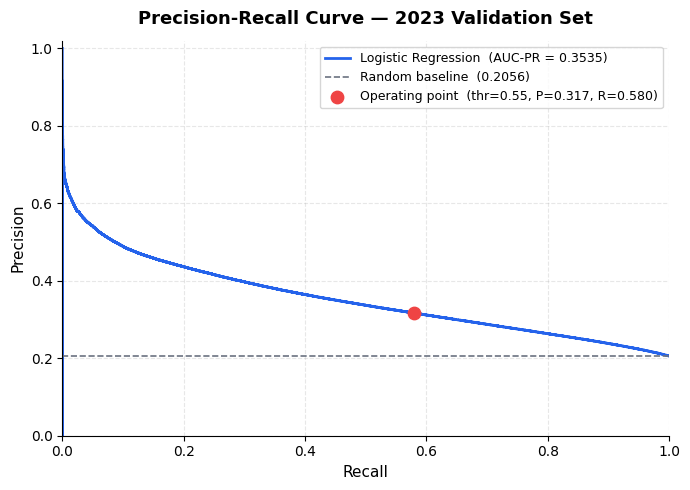

Saved: pr_curve.png


In [41]:
# Visualisations

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sklearn.metrics import precision_recall_curve, auc

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

BLUE   = '#2563EB'
ORANGE = '#F97316'
RED    = '#EF4444'
GREY   = '#6B7280'

# 1. Precision-Recall Curve
# First need to collect probability scores and true labels from Spark into pandas
pr_pd = (
    val_with_prob
    .select('prob_pos', TARGET_COL)
    .toPandas()
)
y_true  = pr_pd[TARGET_COL].astype(int).values
y_score = pr_pd['prob_pos'].values

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall_vals, precision_vals)
random_baseline = y_true.mean()          # class prevalence ≈ 0.19

# Operating point at the locked threshold
thr_idx = np.argmin(np.abs(pr_thresholds - best_threshold))
op_prec = precision_vals[thr_idx]
op_rec  = recall_vals[thr_idx]

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(recall_vals, precision_vals, color=BLUE, lw=2, label=f'Logistic Regression  (AUC-PR = {pr_auc:.4f})')
ax.axhline(random_baseline, color=GREY, lw=1.2, ls='--', label=f'Random baseline  ({random_baseline:.4f})')
ax.scatter(op_rec, op_prec, color=RED, zorder=5, s=80,
           label=f'Operating point  (thr={best_threshold}, P={op_prec:.3f}, R={op_rec:.3f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve — 2023 Validation Set', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pr_curve.png')

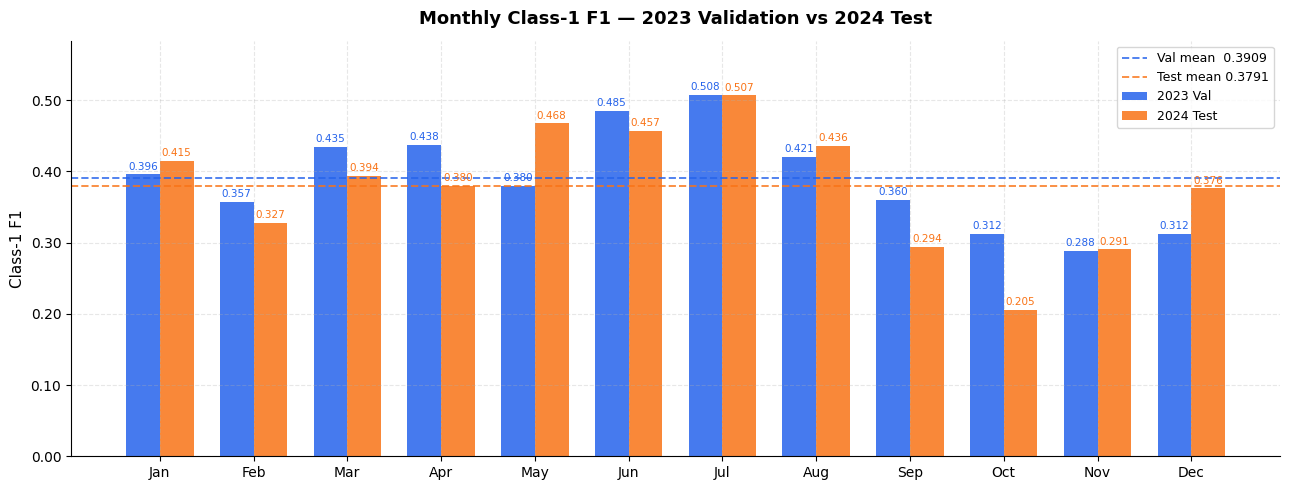

Saved: monthly_f1_val_vs_test.png


In [42]:
# 2. Monthly F1 — Val vs Test (Side by Side)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

val_f1s  = [r[1] for r in monthly_results]          # §9
test_f1s = [r[1] for r in test_monthly_results]      # §11

x      = np.arange(12)
width  = 0.36

val_mean  = np.mean(val_f1s)
test_mean = np.mean(test_f1s)

fig, ax = plt.subplots(figsize=(13, 5))

bars_val  = ax.bar(x - width/2, val_f1s,  width, color=BLUE,   alpha=0.85, label='2023 Val')
bars_test = ax.bar(x + width/2, test_f1s, width, color=ORANGE, alpha=0.85, label='2024 Test')

ax.axhline(val_mean,  color=BLUE,   lw=1.4, ls='--', alpha=0.8,
           label=f'Val mean  {val_mean:.4f}')
ax.axhline(test_mean, color=ORANGE, lw=1.4, ls='--', alpha=0.8,
           label=f'Test mean {test_mean:.4f}')

# Value labels on top of each bar
for bar in bars_val:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color=BLUE)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color=ORANGE)

ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=10)
ax.set_ylabel('Class-1 F1', fontsize=11)
ax.set_title('Monthly Class-1 F1 — 2023 Validation vs 2024 Test', fontsize=13,
             fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
y_max = max(max(val_f1s), max(test_f1s))
ax.set_ylim(0, y_max * 1.15)

plt.tight_layout()
plt.savefig('monthly_f1_val_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monthly_f1_val_vs_test.png')

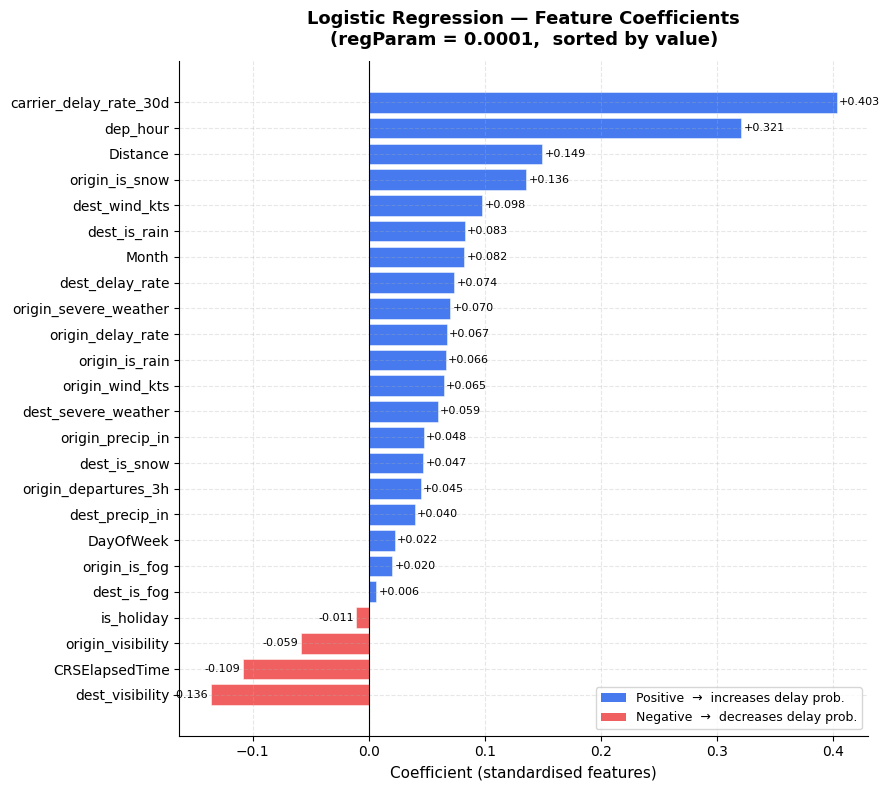

Saved: feature_coefficients.png


In [43]:
# 3. Feature Coefficients Bar Chart
coef_sorted = coef_df.sort_values('coefficient')

colors = [BLUE if c > 0 else RED for c in coef_sorted['coefficient']]

fig, ax = plt.subplots(figsize=(9, 8))

bars = ax.barh(coef_sorted['feature'], coef_sorted['coefficient'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)

ax.axvline(0, color='black', lw=0.8)

# Value labels
for bar, val in zip(bars, coef_sorted['coefficient']):
    pad  = 0.002 if val >= 0 else -0.002
    ha   = 'left' if val >= 0 else 'right'
    ax.text(val + pad, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=8)

ax.set_xlabel('Coefficient (standardised features)', fontsize=11)
ax.set_title('Logistic Regression — Feature Coefficients\n'
             f'(regParam = {best_reg},  sorted by value)',
             fontsize=13, fontweight='bold', pad=12)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=BLUE,  alpha=0.85, label='Positive  →  increases delay prob.'),
                   Patch(facecolor=RED,   alpha=0.85, label='Negative  →  decreases delay prob.')]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_coefficients.png')